Loading dataset...
Dataset Shape: (1048575, 9)

Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

First 5 rows:
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23

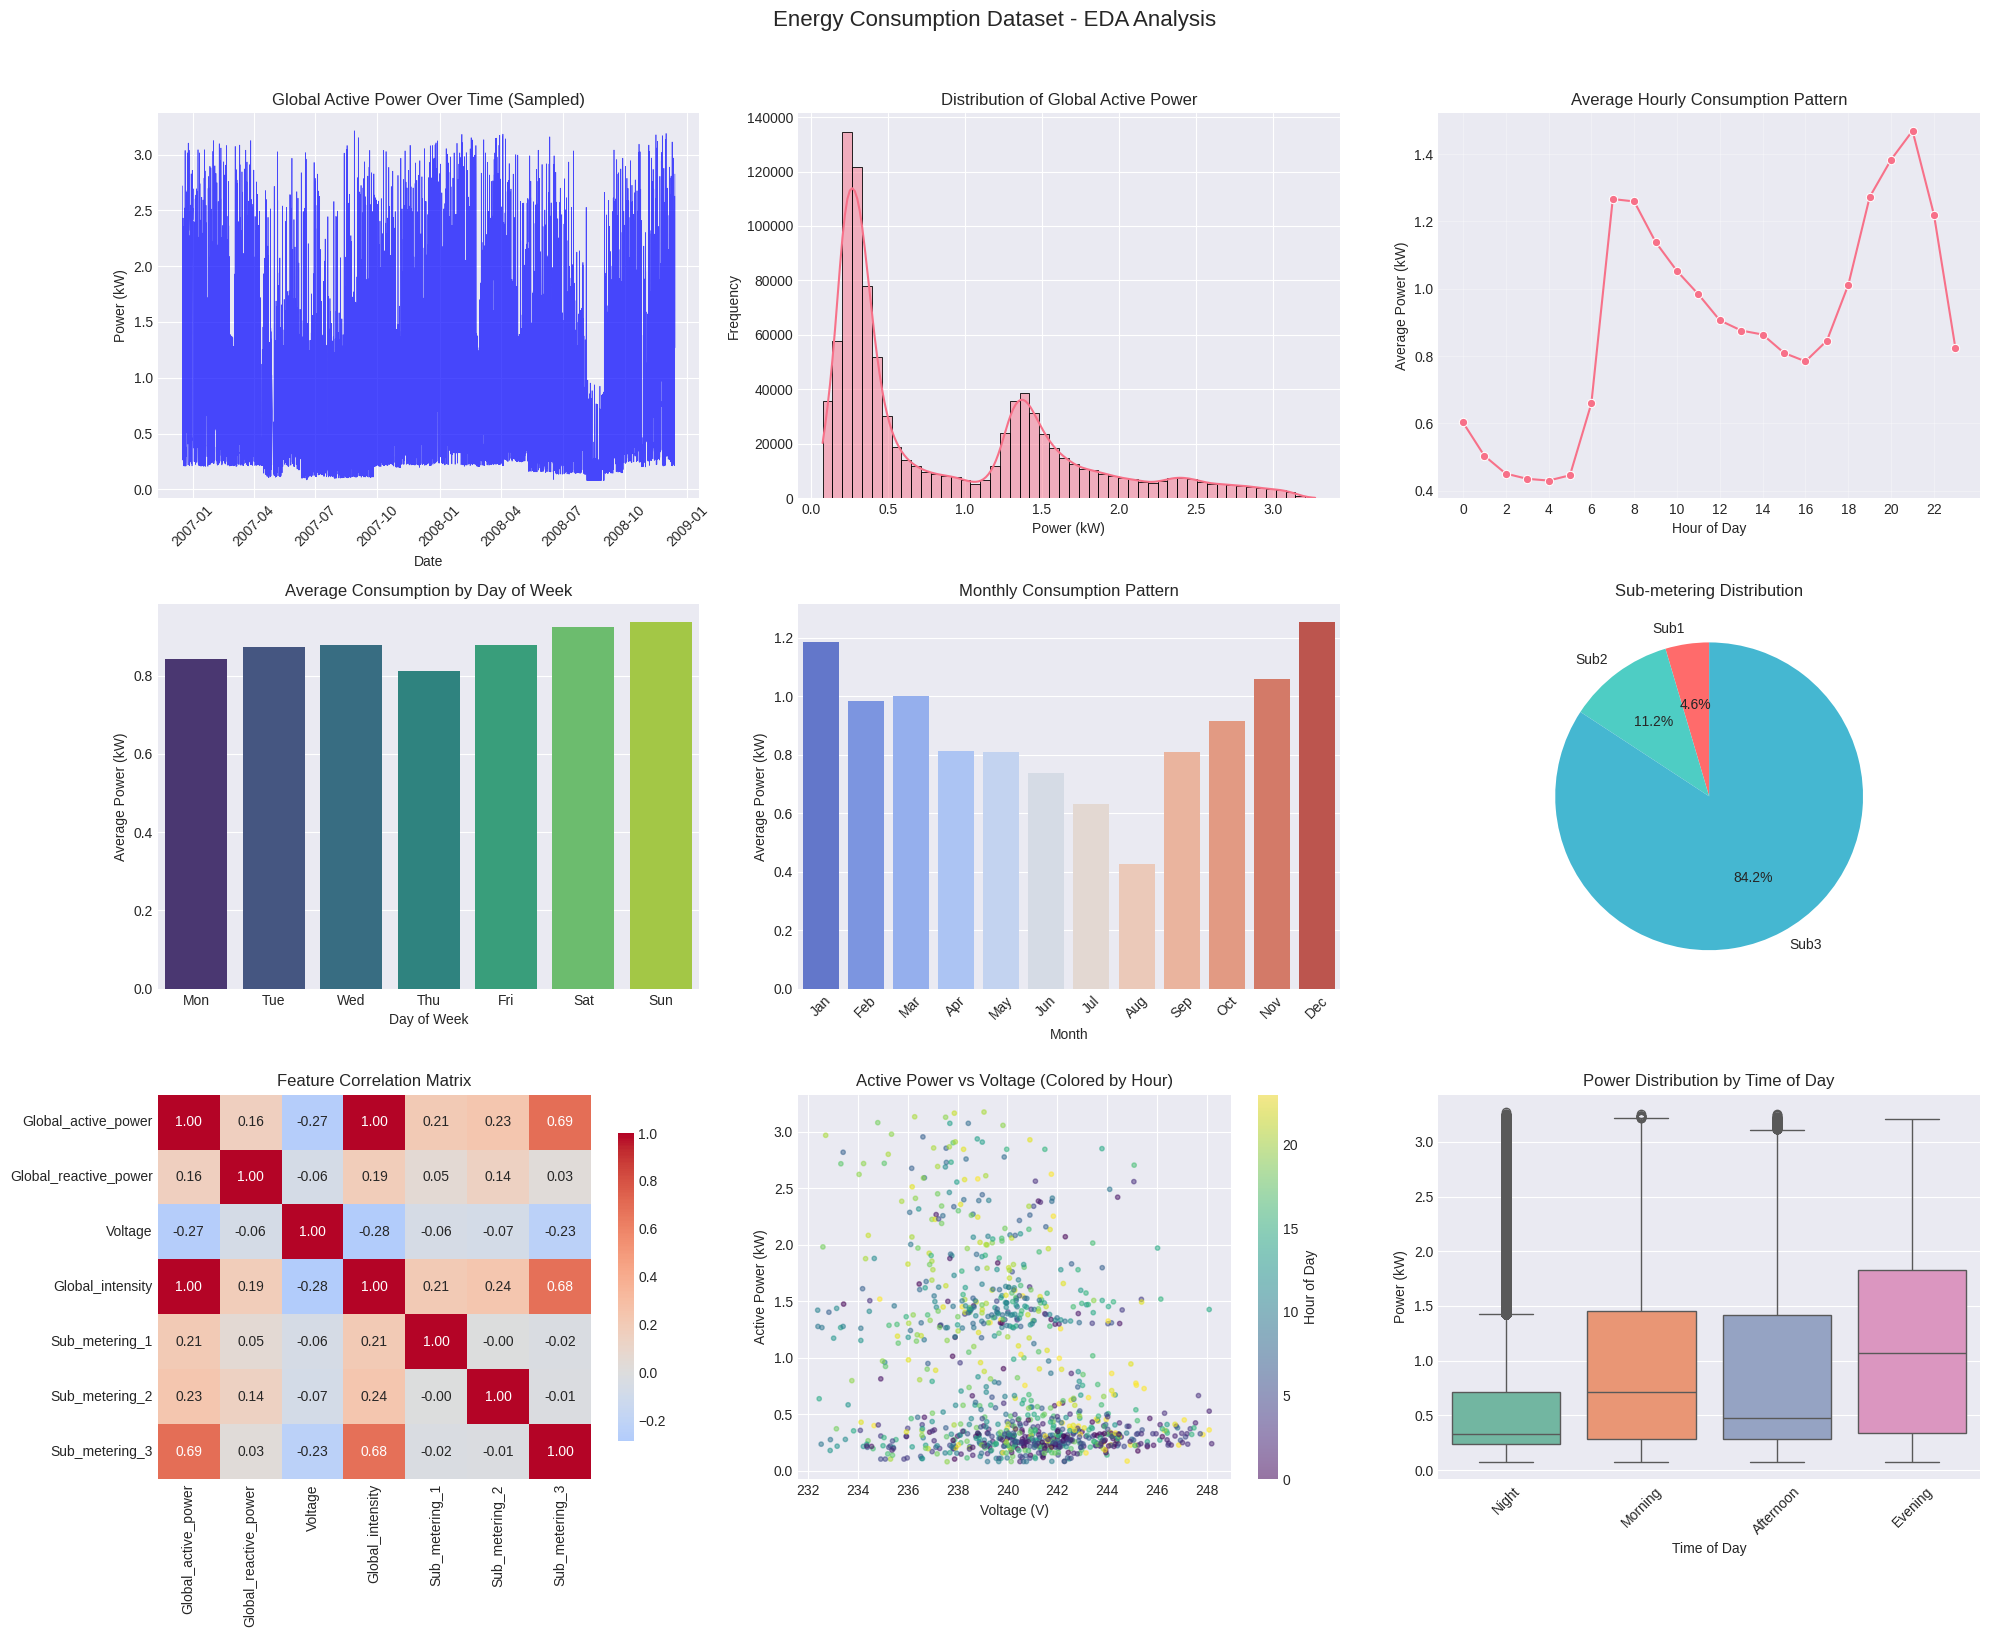


KEY INSIGHTS FROM EDA
1. Power Statistics:
   Average power: 0.877 kW
   Max power: 3.27 kW
   Min power: 0.08 kW
   Std deviation: 0.763 kW

2. Peak consumption hour: 21:00 (1.47 kW)

3. Data Time Range:
   From: 2006-12-16 17:54:00
   To: 2008-12-13 21:38:00
   Duration: 728 days, 3 hours

4. Data Quality Summary:
   Original rows: 1048575
   Cleaned rows: 953182
   Data retention: 90.9%
   Missing values in cleaned data: 0

CONTINUING WITH BASELINE MODELING...


In [ ]:
# ============================================
# 1. INITIAL SETUP & IMPORTS
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# 2. DATA LOADING & INITIAL INSPECTION
# ============================================
print("Loading dataset...")
df = pd.read_csv('household_power_consumption.csv', na_values=['?', 'NA', 'N/A', 'null', 'NULL', '', ' '])

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData Types:")
print(df.dtypes)

print(f"\nSample of unique values in each column:")
for col in df.columns:
    if col not in ['Date', 'Time']:
        unique_vals = df[col].dropna().unique()
        if len(unique_vals) < 10:
            print(f"{col}: {unique_vals[:10]}")
        else:
            print(f"{col}: {len(unique_vals)} unique values (first 3: {unique_vals[:3]})")

# ============================================
# 3. DATA CLEANING
# ============================================
print("\n" + "="*50)
print("DATA CLEANING PHASE")
print("="*50)

# First, convert numeric columns from strings to numbers
print("\nConverting string values to numeric...")
numeric_columns = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                   'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in numeric_columns:
    if df[col].dtype == 'object':
        # Try to convert to numeric, coerce errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"Converted {col} to numeric. New dtype: {df[col].dtype}")

        # Check conversion success
        non_numeric = df[col].isna().sum() - df[col].isna().sum()  # This would show conversion failures
        if non_numeric > 0:
            print(f"  Warning: {non_numeric} values could not be converted to numeric in {col}")

# Check for missing values
print("\nMissing Values Before Cleaning:")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

# Check for zeros/negative values in key columns (NOW SAFE)
key_columns = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
print("\nZero/Invalid Values in Key Columns:")
for col in key_columns:
    # Check if column exists and is numeric
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        zeros = (df[col] <= 0).sum()
        if zeros > 0:
            print(f"{col}: {zeros} zero/negative values ({zeros/len(df)*100:.2f}%)")
    else:
        print(f"{col}: Column not found or not numeric")

# Create datetime column
print("\nCreating datetime column...")
try:
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
    print("Datetime conversion successful")
except Exception as e:
    print(f"Datetime conversion failed: {e}")
    # Try alternative format
    try:
        df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
        print("Datetime conversion successful with default format")
    except:
        print("Could not create datetime column")

# Check for duplicate timestamps
if 'datetime' in df.columns:
    duplicates = df['datetime'].duplicated().sum()
    print(f"Duplicate timestamps: {duplicates}")
else:
    print("No datetime column created")

# Handle missing values
print("\nCleaning Data...")
df_clean = df.copy()

# Drop rows with missing values in key columns
print(f"Original data shape: {df_clean.shape}")
df_clean = df_clean.dropna(subset=key_columns)
print(f"After dropping rows with missing key values: {df_clean.shape}")

# Remove zero/negative values in active power (physically impossible)
original_len = len(df_clean)
df_clean = df_clean[df_clean['Global_active_power'] > 0]
print(f"After removing zero/negative active power: {df_clean.shape} (removed {original_len - len(df_clean)} rows)")

# Remove outliers using IQR method for key metrics
def remove_outliers_iqr(df, column):
    if column in df.columns and pd.api.types.is_numeric_dtype(df[column]):
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

print("\nRemoving outliers...")
for col in key_columns:
    if col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col]):
        original_len = len(df_clean)
        df_clean = remove_outliers_iqr(df_clean, col)
        removed = original_len - len(df_clean)
        if removed > 0:
            print(f"Removed {removed} outliers from {col} ({removed/original_len*100:.2f}%)")

print(f"\nFinal data after cleaning: {df_clean.shape}")
print("Missing Values After Cleaning:")
missing_after = df_clean.isnull().sum()
print(missing_after[missing_after > 0])

# ============================================
# 4. FEATURE ENGINEERING
# ============================================
print("\n" + "="*50)
print("FEATURE ENGINEERING")
print("="*50)

# Ensure datetime column exists
if 'datetime' not in df_clean.columns:
    print("Creating datetime column...")
    df_clean['datetime'] = pd.to_datetime(df_clean['Date'] + ' ' + df_clean['Time'])

# Sort by datetime
df_clean = df_clean.sort_values('datetime')

# Extract temporal features
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['day_of_week'] = df_clean['datetime'].dt.dayofweek
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['day_of_year'] = df_clean['datetime'].dt.dayofyear
df_clean['is_weekend'] = df_clean['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df_clean['quarter'] = df_clean['datetime'].dt.quarter

# Time of day categories
def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df_clean['time_of_day'] = df_clean['hour'].apply(time_of_day)

# Ensure sub-metering columns are numeric
for col in ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
    if col in df_clean.columns and not pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Calculate total sub-metered power (in kWh, divide by 1000 if needed)
if all(col in df_clean.columns for col in ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']):
    df_clean['Total_sub_metered'] = df_clean['Sub_metering_1'] + df_clean['Sub_metering_2'] + df_clean['Sub_metering_3']
    print("Total_sub_metered calculated")
else:
    print("Warning: Some sub-metering columns missing")

# Calculate power factor (cosine phi) - ensure columns are numeric
if all(col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col])
       for col in ['Global_active_power', 'Global_reactive_power']):
    df_clean['Apparent_power'] = np.sqrt(df_clean['Global_active_power']**2 + df_clean['Global_reactive_power']**2)
    df_clean['Power_factor'] = df_clean['Global_active_power'] / df_clean['Apparent_power']
    df_clean['Power_factor'] = df_clean['Power_factor'].replace([np.inf, -np.inf], np.nan).fillna(0)
    print("Power factor calculated")
else:
    print("Warning: Could not calculate power factor - missing numeric columns")

# Rolling statistics
print("Calculating rolling statistics...")
try:
    df_clean['hourly_avg_power'] = df_clean['Global_active_power'].rolling(window=60, min_periods=1).mean()
    df_clean['daily_avg_power'] = df_clean['Global_active_power'].rolling(window=1440, min_periods=1).mean()
    print("Rolling statistics calculated")
except Exception as e:
    print(f"Could not calculate rolling stats: {e}")

print(f"\nTotal engineered features: {len(df_clean.columns) - len(df.columns)}")
print("New features created: hour, day_of_week, month, is_weekend, time_of_day, etc.")

# ============================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# Set up the figure for EDA plots
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Energy Consumption Dataset - EDA Analysis', fontsize=16, y=1.02)

# 5.1 Time Series Plot (Sampled for clarity)
ax1 = plt.subplot(3, 3, 1)
if len(df_clean) > 1000:
    sample_df = df_clean.iloc[::100]  # Sample every 100th point
else:
    sample_df = df_clean

if 'datetime' in sample_df.columns and 'Global_active_power' in sample_df.columns:
    ax1.plot(sample_df['datetime'], sample_df['Global_active_power'],
             linewidth=0.5, alpha=0.7, color='blue')
    ax1.set_title('Global Active Power Over Time (Sampled)', fontsize=12)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Power (kW)')
    ax1.tick_params(axis='x', rotation=45)
else:
    ax1.text(0.5, 0.5, 'Data not available', ha='center', va='center')
    ax1.set_title('Global Active Power Over Time', fontsize=12)

# 5.2 Distribution of Active Power
ax2 = plt.subplot(3, 3, 2)
if 'Global_active_power' in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean['Global_active_power']):
    sns.histplot(df_clean['Global_active_power'].dropna(), bins=50, kde=True, ax=ax2)
    ax2.set_title('Distribution of Global Active Power', fontsize=12)
    ax2.set_xlabel('Power (kW)')
    ax2.set_ylabel('Frequency')
else:
    ax2.text(0.5, 0.5, 'Data not available', ha='center', va='center')
    ax2.set_title('Distribution of Global Active Power', fontsize=12)

# 5.3 Hourly Consumption Pattern
ax3 = plt.subplot(3, 3, 3)
if 'hour' in df_clean.columns and 'Global_active_power' in df_clean.columns:
    hourly_avg = df_clean.groupby('hour')['Global_active_power'].mean()
    if not hourly_avg.empty:
        sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o', ax=ax3)
        ax3.set_title('Average Hourly Consumption Pattern', fontsize=12)
        ax3.set_xlabel('Hour of Day')
        ax3.set_ylabel('Average Power (kW)')
        ax3.set_xticks(range(0, 24, 2))
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'No hourly data', ha='center', va='center')
        ax3.set_title('Average Hourly Consumption Pattern', fontsize=12)
else:
    ax3.text(0.5, 0.5, 'Data not available', ha='center', va='center')
    ax3.set_title('Average Hourly Consumption Pattern', fontsize=12)

# 5.4 Weekly Pattern
ax4 = plt.subplot(3, 3, 4)
if 'day_of_week' in df_clean.columns and 'Global_active_power' in df_clean.columns:
    weekly_avg = df_clean.groupby('day_of_week')['Global_active_power'].mean()
    if not weekly_avg.empty:
        weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
        sns.barplot(x=weekday_names, y=weekly_avg.values, ax=ax4, palette='viridis')
        ax4.set_title('Average Consumption by Day of Week', fontsize=12)
        ax4.set_xlabel('Day of Week')
        ax4.set_ylabel('Average Power (kW)')
    else:
        ax4.text(0.5, 0.5, 'No weekly data', ha='center', va='center')
        ax4.set_title('Average Consumption by Day of Week', fontsize=12)
else:
    ax4.text(0.5, 0.5, 'Data not available', ha='center', va='center')
    ax4.set_title('Average Consumption by Day of Week', fontsize=12)

# 5.5 Monthly/Seasonal Pattern
ax5 = plt.subplot(3, 3, 5)
if 'month' in df_clean.columns and 'Global_active_power' in df_clean.columns:
    monthly_avg = df_clean.groupby('month')['Global_active_power'].mean()
    if not monthly_avg.empty:
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        # Filter to available months
        available_months = [month_names[i-1] for i in monthly_avg.index if 1 <= i <= 12]
        sns.barplot(x=available_months, y=monthly_avg.values, ax=ax5, palette='coolwarm')
        ax5.set_title('Monthly Consumption Pattern', fontsize=12)
        ax5.set_xlabel('Month')
        ax5.set_ylabel('Average Power (kW)')
        ax5.tick_params(axis='x', rotation=45)
    else:
        ax5.text(0.5, 0.5, 'No monthly data', ha='center', va='center')
        ax5.set_title('Monthly Consumption Pattern', fontsize=12)
else:
    ax5.text(0.5, 0.5, 'Data not available', ha='center', va='center')
    ax5.set_title('Monthly Consumption Pattern', fontsize=12)

# 5.6 Sub-metering Breakdown
ax6 = plt.subplot(3, 3, 6)
sub_meter_cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
available_sub_meters = [col for col in sub_meter_cols if col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col])]

if available_sub_meters:
    sub_meter_avg = df_clean[available_sub_meters].mean()
    if not sub_meter_avg.empty and sub_meter_avg.sum() > 0:
        labels = [f'Sub{i+1}' for i in range(len(available_sub_meters))]
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1'][:len(available_sub_meters)]
        ax6.pie(sub_meter_avg.values, labels=labels,
                autopct='%1.1f%%', colors=colors, startangle=90)
        ax6.set_title('Sub-metering Distribution', fontsize=12)
    else:
        ax6.text(0.5, 0.5, 'No sub-metering data', ha='center', va='center')
        ax6.set_title('Sub-metering Distribution', fontsize=12)
else:
    ax6.text(0.5, 0.5, 'Sub-metering not available', ha='center', va='center')
    ax6.set_title('Sub-metering Distribution', fontsize=12)

# 5.7 Correlation Heatmap
ax7 = plt.subplot(3, 3, 7)
corr_columns = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
                'Sub_metering_3']

# Filter to available numeric columns
available_corr_cols = [col for col in corr_columns
                       if col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col])]

if len(available_corr_cols) >= 2:
    correlation_matrix = df_clean[available_corr_cols].corr()
    if not correlation_matrix.empty:
        sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, ax=ax7, cbar_kws={'shrink': 0.8})
        ax7.set_title('Feature Correlation Matrix', fontsize=12)
    else:
        ax7.text(0.5, 0.5, 'No correlation data', ha='center', va='center')
        ax7.set_title('Feature Correlation Matrix', fontsize=12)
else:
    ax7.text(0.5, 0.5, 'Insufficient data for correlation', ha='center', va='center')
    ax7.set_title('Feature Correlation Matrix', fontsize=12)

# 5.8 Power vs Voltage Scatter
ax8 = plt.subplot(3, 3, 8)
if 'Voltage' in df_clean.columns and 'Global_active_power' in df_clean.columns and 'hour' in df_clean.columns:
    if pd.api.types.is_numeric_dtype(df_clean['Voltage']) and pd.api.types.is_numeric_dtype(df_clean['Global_active_power']):
        # Sample for performance
        sample_size = min(1000, len(df_clean))
        scatter_data = df_clean.iloc[::max(1, len(df_clean)//sample_size)]

        scatter = ax8.scatter(scatter_data['Voltage'],
                              scatter_data['Global_active_power'],
                              c=scatter_data['hour'],
                              cmap='viridis', alpha=0.5, s=10)
        ax8.set_title('Active Power vs Voltage (Colored by Hour)', fontsize=12)
        ax8.set_xlabel('Voltage (V)')
        ax8.set_ylabel('Active Power (kW)')
        plt.colorbar(scatter, ax=ax8, label='Hour of Day')
    else:
        ax8.text(0.5, 0.5, 'Numeric data required', ha='center', va='center')
        ax8.set_title('Active Power vs Voltage', fontsize=12)
else:
    ax8.text(0.5, 0.5, 'Data not available', ha='center', va='center')
    ax8.set_title('Active Power vs Voltage', fontsize=12)

# 5.9 Boxplot by Time of Day
ax9 = plt.subplot(3, 3, 9)
if 'time_of_day' in df_clean.columns and 'Global_active_power' in df_clean.columns:
    time_order = ['Night', 'Morning', 'Afternoon', 'Evening']
    # Filter to only available time categories
    available_times = [t for t in time_order if t in df_clean['time_of_day'].unique()]

    if available_times and pd.api.types.is_numeric_dtype(df_clean['Global_active_power']):
        sns.boxplot(x='time_of_day', y='Global_active_power',
                    data=df_clean, order=available_times, ax=ax9, palette='Set2')
        ax9.set_title('Power Distribution by Time of Day', fontsize=12)
        ax9.set_xlabel('Time of Day')
        ax9.set_ylabel('Power (kW)')
        ax9.tick_params(axis='x', rotation=45)
    else:
        ax9.text(0.5, 0.5, 'No time category data', ha='center', va='center')
        ax9.set_title('Power Distribution by Time of Day', fontsize=12)
else:
    ax9.text(0.5, 0.5, 'Data not available', ha='center', va='center')
    ax9.set_title('Power Distribution by Time of Day', fontsize=12)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print key insights
print("\n" + "="*50)
print("KEY INSIGHTS FROM EDA")
print("="*50)

# Insight 1: Basic statistics
if 'Global_active_power' in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean['Global_active_power']):
    print(f"1. Power Statistics:")
    print(f"   Average power: {df_clean['Global_active_power'].mean():.3f} kW")
    print(f"   Max power: {df_clean['Global_active_power'].max():.2f} kW")
    print(f"   Min power: {df_clean['Global_active_power'].min():.2f} kW")
    print(f"   Std deviation: {df_clean['Global_active_power'].std():.3f} kW")

# Insight 2: Peak hours
if 'hour' in df_clean.columns and 'Global_active_power' in df_clean.columns:
    hourly_avg = df_clean.groupby('hour')['Global_active_power'].mean()
    if not hourly_avg.empty:
        peak_hour = hourly_avg.idxmax()
        peak_value = hourly_avg.max()
        print(f"\n2. Peak consumption hour: {peak_hour}:00 ({peak_value:.2f} kW)")

# Insight 3: Time range
if 'datetime' in df_clean.columns:
    print(f"\n3. Data Time Range:")
    print(f"   From: {df_clean['datetime'].min()}")
    print(f"   To: {df_clean['datetime'].max()}")
    duration = df_clean['datetime'].max() - df_clean['datetime'].min()
    print(f"   Duration: {duration.days} days, {duration.seconds//3600} hours")

# Insight 4: Data quality
print(f"\n4. Data Quality Summary:")
print(f"   Original rows: {len(df)}")
print(f"   Cleaned rows: {len(df_clean)}")
print(f"   Data retention: {len(df_clean)/len(df)*100:.1f}%")
print(f"   Missing values in cleaned data: {df_clean.isnull().sum().sum()}")

print("\n" + "="*50)
print("CONTINUING WITH BASELINE MODELING...")
print("="*50)




BASELINE MODEL IMPLEMENTATION - ENHANCED

Preparing data for modeling...
Hourly data shape: (17315, 4)
Date range: 2006-12-16 17:00:00 to 2008-12-13 21:00:00

Training samples: 13852
Testing samples: 3463
Training period: 2006-12-16 17:00 to 2008-07-22 03:00
Testing period: 2008-07-22 04:00 to 2008-12-13 21:00

MODEL 1: SARIMAX (Recommended for Seasonality)
Fitting SARIMAX(1,1,1)(1,1,1,24) model...

SARIMAX Model Summary:
                                     SARIMAX Results                                      
Dep. Variable:                Global_active_power   No. Observations:                13852
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -9159.716
Date:                            Wed, 11 Mar 2026   AIC                          18329.431
Time:                                    09:32:03   BIC                          18367.094
Sample:                                12-16-2006   HQIC                         18341.978
                           

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



ARIMA Model Summary:
                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                13852
Model:                  ARIMA(2, 1, 2)   Log Likelihood               -9704.464
Date:                 Wed, 11 Mar 2026   AIC                          19418.927
Time:                         09:32:12   BIC                          19456.608
Sample:                     12-16-2006   HQIC                         19431.478
                          - 07-22-2008                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4028      0.029     47.637      0.000       1.345       1.461
ar.L2         -0.5643      0.019    -29.808      0.000      -0.601      -0.527
ma.L1         -1.6267 

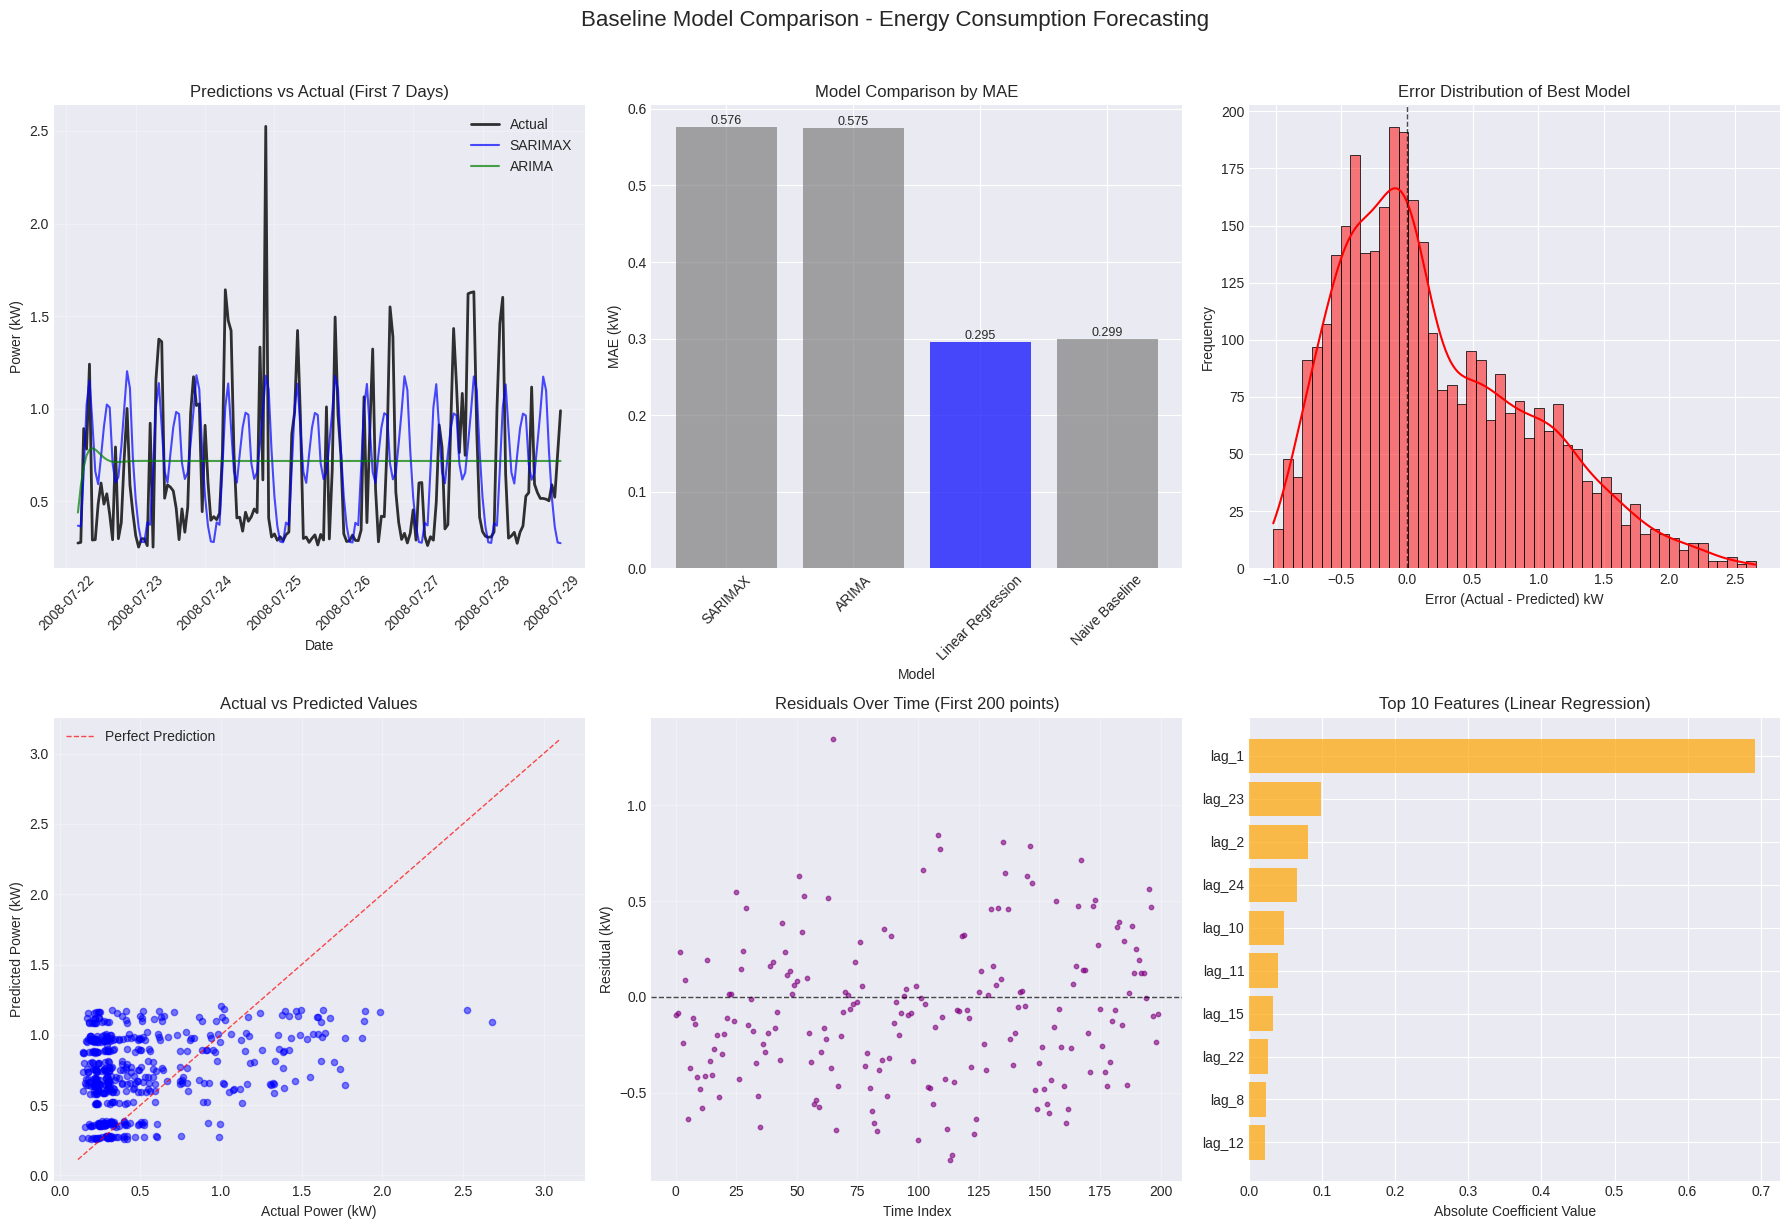

In [ ]:
# ============================================
# 7. BASELINE MODEL IMPLEMENTATION - FIXED VERSION
# ============================================
print("\n" + "="*50)
print("BASELINE MODEL IMPLEMENTATION - ENHANCED")
print("="*50)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import math

# Prepare data for modeling
print("\nPreparing data for modeling...")

# Resample to hourly data
df_hourly = df_clean.set_index('datetime').resample('H').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean'
}).dropna()

print(f"Hourly data shape: {df_hourly.shape}")
print(f"Date range: {df_hourly.index.min()} to {df_hourly.index.max()}")

# Add frequency to index for ARIMA/SARIMAX
df_hourly.index = pd.DatetimeIndex(df_hourly.index).to_period('H')

# Split data into train and test (80-20 split)
train_size = int(len(df_hourly) * 0.8)
train_data = df_hourly['Global_active_power'].iloc[:train_size]
test_data = df_hourly['Global_active_power'].iloc[train_size:]

print(f"\nTraining samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")
print(f"Training period: {train_data.index.min()} to {train_data.index.max()}")
print(f"Testing period: {test_data.index.min()} to {test_data.index.max()}")

# ============================================
# MODEL 1: SARIMAX (Seasonal ARIMA with eXogenous variables)
# ============================================
print("\n" + "="*50)
print("MODEL 1: SARIMAX (Recommended for Seasonality)")
print("="*50)

try:
    # Based on hourly data, use seasonal period of 24 (daily) and 168 (weekly)
    # Using simpler parameters to avoid overlap issue
    print("Fitting SARIMAX(1,1,1)(1,1,1,24) model...")

    # Fit SARIMAX model
    sarimax_model = SARIMAX(train_data,
                           order=(1, 1, 1),
                           seasonal_order=(1, 1, 1, 24),
                           enforce_stationarity=False,
                           enforce_invertibility=False)

    sarimax_fit = sarimax_model.fit(disp=False)

    print("\nSARIMAX Model Summary:")
    print(sarimax_fit.summary())

    # Make predictions
    sarimax_predictions = sarimax_fit.forecast(steps=len(test_data))

    # Calculate metrics
    sarimax_mae = mean_absolute_error(test_data, sarimax_predictions)
    sarimax_rmse = math.sqrt(mean_squared_error(test_data, sarimax_predictions))

    # Custom MAPE calculation that handles zeros
    def safe_mape(y_true, y_pred):
        # Avoid division by zero
        mask = y_true != 0
        if mask.sum() == 0:
            return np.nan
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    sarimax_mape = safe_mape(test_data.values, sarimax_predictions.values)

    print("\nSARIMAX Performance Metrics:")
    print(f"Mean Absolute Error (MAE): {sarimax_mae:.4f} kW")
    print(f"Root Mean Square Error (RMSE): {sarimax_rmse:.4f} kW")
    if not np.isnan(sarimax_mape):
        print(f"Mean Absolute Percentage Error (MAPE): {sarimax_mape:.2f}%")
    else:
        print(f"MAPE: Cannot calculate (zero values in test data)")

    # Save SARIMAX results
    sarimax_success = True

except Exception as e:
    print(f"\nSARIMAX modeling failed: {e}")
    print("Trying simpler SARIMA model...")

    try:
        # Try simpler seasonal model
        sarimax_model_simple = SARIMAX(train_data,
                                      order=(1, 1, 1),
                                      seasonal_order=(0, 1, 1, 24),
                                      enforce_stationarity=False,
                                      enforce_invertibility=False)

        sarimax_fit_simple = sarimax_model_simple.fit(disp=False)
        sarimax_predictions = sarimax_fit_simple.forecast(steps=len(test_data))

        sarimax_mae = mean_absolute_error(test_data, sarimax_predictions)
        sarimax_rmse = math.sqrt(mean_squared_error(test_data, sarimax_predictions))
        sarimax_mape = safe_mape(test_data.values, sarimax_predictions.values)

        print(f"\nSimple SARIMA Performance:")
        print(f"MAE: {sarimax_mae:.4f} kW")
        print(f"RMSE: {sarimax_rmse:.4f} kW")
        if not np.isnan(sarimax_mape):
            print(f"MAPE: {sarimax_mape:.2f}%")

        sarimax_success = True

    except Exception as e2:
        print(f"Even simple SARIMA failed: {e2}")
        sarimax_success = False

# ============================================
# MODEL 2: Simple ARIMA (Non-seasonal)
# ============================================
print("\n" + "="*50)
print("MODEL 2: Simple ARIMA")
print("="*50)

try:
    print("Fitting ARIMA(2,1,2) model...")

    # Fit simple ARIMA model
    arima_model = ARIMA(train_data, order=(2, 1, 2))
    arima_fit = arima_model.fit()

    print("\nARIMA Model Summary:")
    print(arima_fit.summary())

    # Make predictions
    arima_predictions = arima_fit.forecast(steps=len(test_data))

    # Calculate metrics
    arima_mae = mean_absolute_error(test_data, arima_predictions)
    arima_rmse = math.sqrt(mean_squared_error(test_data, arima_predictions))
    arima_mape = safe_mape(test_data.values, arima_predictions.values)

    print("\nARIMA Performance Metrics:")
    print(f"Mean Absolute Error (MAE): {arima_mae:.4f} kW")
    print(f"Root Mean Square Error (RMSE): {arima_rmse:.4f} kW")
    if not np.isnan(arima_mape):
        print(f"Mean Absolute Percentage Error (MAPE): {arima_mape:.2f}%")

    arima_success = True

except Exception as e:
    print(f"ARIMA modeling failed: {e}")
    arima_success = False

# ============================================
# MODEL 3: Linear Regression with Lag Features
# ============================================
print("\n" + "="*50)
print("MODEL 3: Linear Regression with Lag Features")
print("="*50)

# Prepare features for linear regression
print("\nPreparing features for Linear Regression...")

# Create lag features dataframe
lr_data = df_hourly.copy()

# Create lag features (previous 1-24 hours)
for lag in range(1, 25):
    lr_data[f'lag_{lag}'] = lr_data['Global_active_power'].shift(lag)

# Create time-based features
lr_data['hour'] = lr_data.index.hour
lr_data['day_of_week'] = lr_data.index.dayofweek
lr_data['is_weekend'] = lr_data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Remove rows with NaN (due to lag creation)
lr_data = lr_data.dropna()

# Define features and target
features = [f'lag_{i}' for i in range(1, 25)] + ['hour', 'day_of_week', 'is_weekend']
X = lr_data[features]
y = lr_data['Global_active_power']

# Split data (same proportion as time series)
lr_train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:lr_train_size], X.iloc[lr_train_size:]
y_train, y_test = y.iloc[:lr_train_size], y.iloc[lr_train_size:]

print(f"Linear Regression training samples: {len(X_train)}")
print(f"Linear Regression testing samples: {len(X_test)}")

# Train Linear Regression model
print("\nTraining Linear Regression model...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

# Calculate metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = math.sqrt(mean_squared_error(y_test, lr_predictions))
lr_mape = safe_mape(y_test.values, lr_predictions)

print("\nLinear Regression Performance Metrics:")
print(f"Mean Absolute Error (MAE): {lr_mae:.4f} kW")
print(f"Root Mean Square Error (RMSE): {lr_rmse:.4f} kW")
if not np.isnan(lr_mape):
    print(f"Mean Absolute Percentage Error (MAPE): {lr_mape:.2f}%")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# ============================================
# MODEL 4: Naive Baseline (Last Value)
# ============================================
print("\n" + "="*50)
print("MODEL 4: Naive Baseline (Last Value)")
print("="*50)

# Simple naive forecast: use last observed value
naive_predictions = np.roll(test_data.values, 1)
naive_predictions[0] = train_data.iloc[-1]

naive_mae = mean_absolute_error(test_data, naive_predictions)
naive_rmse = math.sqrt(mean_squared_error(test_data, naive_predictions))
naive_mape = safe_mape(test_data.values, naive_predictions)

print("\nNaive Baseline Performance:")
print(f"Mean Absolute Error (MAE): {naive_mae:.4f} kW")
print(f"Root Mean Square Error (RMSE): {naive_rmse:.4f} kW")
if not np.isnan(naive_mape):
    print(f"Mean Absolute Percentage Error (MAPE): {naive_mape:.2f}%")

# ============================================
# MODEL COMPARISON
# ============================================
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

# Create comparison table
comparison_data = []

# Add models that succeeded
if sarimax_success:
    comparison_data.append({
        'Model': 'SARIMAX',
        'MAE': sarimax_mae,
        'RMSE': sarimax_rmse,
        'MAPE': sarimax_mape if not np.isnan(sarimax_mape) else 'N/A',
        'Description': 'Seasonal ARIMA with daily seasonality'
    })

if arima_success:
    comparison_data.append({
        'Model': 'ARIMA',
        'MAE': arima_mae,
        'RMSE': arima_rmse,
        'MAPE': arima_mape if not np.isnan(arima_mape) else 'N/A',
        'Description': 'Non-seasonal ARIMA'
    })

comparison_data.append({
    'Model': 'Linear Regression',
    'MAE': lr_mae,
    'RMSE': lr_rmse,
    'MAPE': lr_mape if not np.isnan(lr_mape) else 'N/A',
    'Description': 'With lag features & time variables'
})

comparison_data.append({
    'Model': 'Naive Baseline',
    'MAE': naive_mae,
    'RMSE': naive_rmse,
    'MAPE': naive_mape if not np.isnan(naive_mape) else 'N/A',
    'Description': 'Last value forecast'
})

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

# Find best model by MAE
best_model_idx = comparison_df['MAE'].idxmin()
best_model = comparison_df.loc[best_model_idx, 'Model']
best_mae = comparison_df.loc[best_model_idx, 'MAE']

print(f"\n🏆 Best Model: {best_model} (MAE: {best_mae:.4f} kW)")

# Calculate improvement over naive baseline
if 'Naive Baseline' in comparison_df['Model'].values:
    naive_mae_value = comparison_df[comparison_df['Model'] == 'Naive Baseline']['MAE'].values[0]
    improvement = ((naive_mae_value - best_mae) / naive_mae_value) * 100
    print(f"Improvement over Naive Baseline: {improvement:.1f}% better")

# ============================================
# VISUALIZATION OF RESULTS
# ============================================
print("\n" + "="*50)
print("VISUALIZING MODEL RESULTS")
print("="*50)

# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Baseline Model Comparison - Energy Consumption Forecasting', fontsize=16, y=1.02)

# Plot 1: All predictions vs actual
ax1 = axes[0, 0]
# Plot only first 168 hours (7 days) for clarity
plot_hours = min(168, len(test_data))

ax1.plot(test_data.index[:plot_hours].to_timestamp(),
         test_data.values[:plot_hours],
         label='Actual', linewidth=2, alpha=0.8, color='black')

if sarimax_success:
    ax1.plot(test_data.index[:plot_hours].to_timestamp(),
             sarimax_predictions.values[:plot_hours],
             label='SARIMAX', linewidth=1.5, alpha=0.7, color='blue')

if arima_success:
    ax1.plot(test_data.index[:plot_hours].to_timestamp(),
             arima_predictions.values[:plot_hours],
             label='ARIMA', linewidth=1.5, alpha=0.7, color='green')

ax1.set_title('Predictions vs Actual (First 7 Days)', fontsize=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Power (kW)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Plot 2: Model comparison by MAE
ax2 = axes[0, 1]
models = comparison_df['Model']
mae_values = comparison_df['MAE']
colors = ['blue' if m == best_model else 'gray' for m in models]

bars = ax2.bar(models, mae_values, color=colors, alpha=0.7)
ax2.set_title('Model Comparison by MAE', fontsize=12)
ax2.set_xlabel('Model')
ax2.set_ylabel('MAE (kW)')
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Error distribution for best model
ax3 = axes[0, 2]
if sarimax_success:
    errors = test_data.values - sarimax_predictions.values
elif arima_success:
    errors = test_data.values - arima_predictions.values
else:
    errors = y_test.values - lr_predictions

sns.histplot(errors, bins=50, kde=True, ax=ax3, color='red')
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.7, linewidth=1)
ax3.set_title('Error Distribution of Best Model', fontsize=12)
ax3.set_xlabel('Error (Actual - Predicted) kW')
ax3.set_ylabel('Frequency')

# Plot 4: Actual vs Predicted scatter
ax4 = axes[1, 0]
if sarimax_success:
    predictions_for_scatter = sarimax_predictions.values
elif arima_success:
    predictions_for_scatter = arima_predictions.values
else:
    predictions_for_scatter = lr_predictions

scatter = ax4.scatter(test_data.values[:500], predictions_for_scatter[:500],
                      alpha=0.5, s=20, c='blue')

# Perfect prediction line
min_val = min(test_data.min(), predictions_for_scatter.min())
max_val = max(test_data.max(), predictions_for_scatter.max())
ax4.plot([min_val, max_val], [min_val, max_val],
         'r--', alpha=0.7, linewidth=1, label='Perfect Prediction')

ax4.set_title('Actual vs Predicted Values', fontsize=12)
ax4.set_xlabel('Actual Power (kW)')
ax4.set_ylabel('Predicted Power (kW)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Residuals over time
ax5 = axes[1, 1]
residuals = test_data.values - predictions_for_scatter
ax5.scatter(range(len(residuals[:200])), residuals[:200],
            alpha=0.6, s=10, color='purple')
ax5.axhline(y=0, color='black', linestyle='--', alpha=0.7, linewidth=1)
ax5.set_title('Residuals Over Time (First 200 points)', fontsize=12)
ax5.set_xlabel('Time Index')
ax5.set_ylabel('Residual (kW)')
ax5.grid(True, alpha=0.3)

# Plot 6: Feature importance from Linear Regression
ax6 = axes[1, 2]
top_features = feature_importance.head(10)
bars = ax6.barh(top_features['feature'], top_features['coefficient'].abs(),
                color='orange', alpha=0.7)
ax6.set_title('Top 10 Features (Linear Regression)', fontsize=12)
ax6.set_xlabel('Absolute Coefficient Value')
ax6.invert_yaxis()  # Highest value at top

plt.tight_layout()
plt.savefig('baseline_model_results.png', dpi=300, bbox_inches='tight')
plt.show()

Epoch 1/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0531 - val_loss: 0.0234
Epoch 2/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0292 - val_loss: 0.0211
Epoch 3/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0273 - val_loss: 0.0212
Epoch 4/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0262 - val_loss: 0.0199
Epoch 5/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0248 - val_loss: 0.0198
Epoch 6/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0247 - val_loss: 0.0195
Epoch 7/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0240 - val_loss: 0.0200
Epoch 8/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0237 - val_loss: 0.0199
Epoch 9/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0241 - val_loss: 0.0200
Epoch 10/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0237 - val_loss: 0.0195
Epoch 11/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0237 - val_loss: 0.0197
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/st

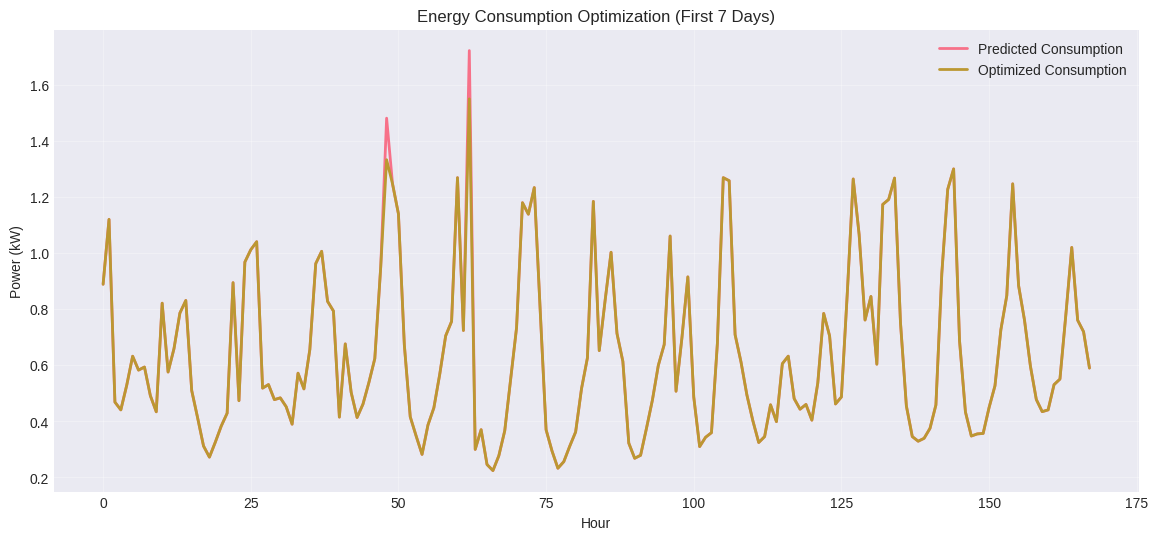

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Use only target variable
data = df_hourly[['Global_active_power']].values

# Scale data (important for LSTM)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, window=24):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

WINDOW_SIZE = 24
X, y = create_sequences(data_scaled, WINDOW_SIZE)

# Train-test split (80-20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape for LSTM [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], WINDOW_SIZE, 1))
X_test = X_test.reshape((X_test.shape[0], WINDOW_SIZE, 1))

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predict
y_pred_scaled = model.predict(X_test)

# Inverse scaling
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

# Metrics
lstm_mae = mean_absolute_error(y_test_actual, y_pred_actual)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("LSTM Performance:")
print(f"MAE  : {lstm_mae:.4f} kW")
print(f"RMSE : {lstm_rmse:.4f} kW")

# Threshold for high demand (top 20%)
threshold = np.percentile(y_pred_actual, 80)

print(f"High-demand threshold: {threshold:.2f} kW")

optimized_consumption = []

for val in y_pred_actual:
    if val > threshold:
        optimized_consumption.append(val * 0.9)  # 10% reduction
    else:
        optimized_consumption.append(val)

optimized_consumption = np.array(optimized_consumption)

# Total energy comparison
original_energy = np.sum(y_pred_actual)
optimized_energy = np.sum(optimized_consumption)

energy_savings = original_energy - optimized_energy
savings_percent = (energy_savings / original_energy) * 100

print("\nENERGY OPTIMIZATION RESULTS")
print(f"Original Energy Usage  : {original_energy:.2f} kWh")
print(f"Optimized Energy Usage : {optimized_energy:.2f} kWh")
print(f"Energy Saved           : {energy_savings:.2f} kWh")
print(f"Savings Percentage     : {savings_percent:.2f}%")

plt.figure(figsize=(14,6))

plt.plot(y_pred_actual[:168], label='Predicted Consumption', linewidth=2)
plt.plot(optimized_consumption[:168], label='Optimized Consumption', linewidth=2)

plt.title('Energy Consumption Optimization (First 7 Days)')
plt.xlabel('Hour')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()



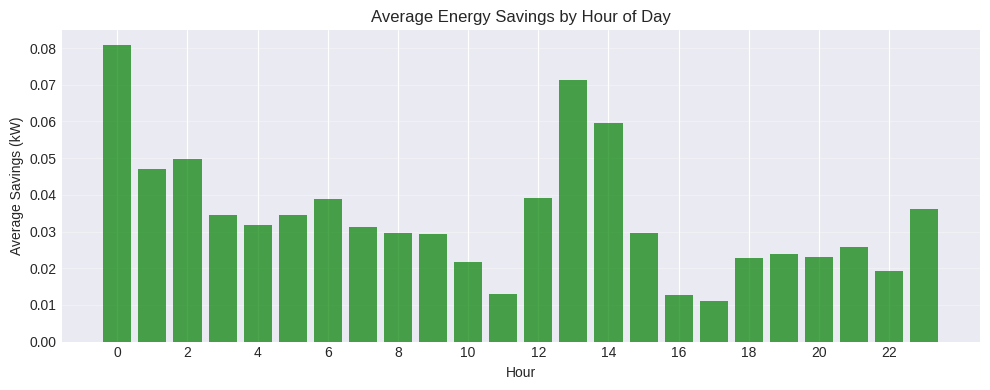

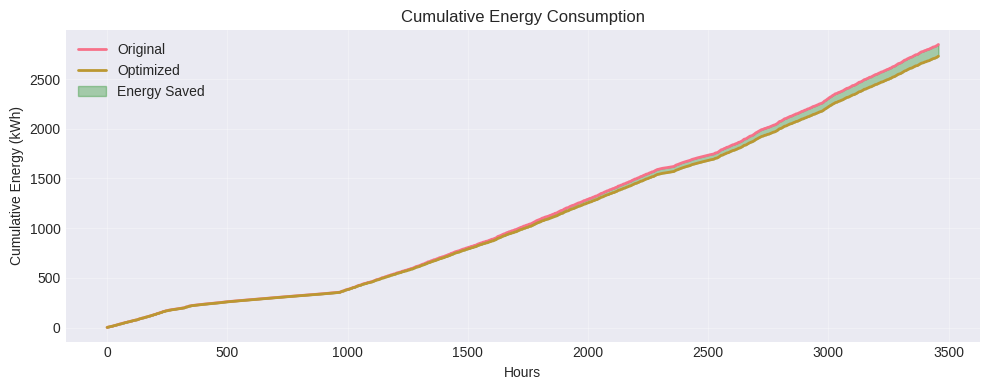

Total Energy Saved: 117.76 kWh
Savings Percentage: 4.13%


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. SAVINGS BY HOUR (Most important)
savings_by_hour = pd.DataFrame({
    'hour': np.tile(range(24), len(y_pred_actual)//24 + 1)[:len(y_pred_actual)],
    'savings': (y_pred_actual.flatten() - optimized_consumption.flatten())
}).groupby('hour')['savings'].mean()

plt.figure(figsize=(10, 4))
plt.bar(savings_by_hour.index, savings_by_hour.values, color='green', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.title('Average Energy Savings by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Savings (kW)')
plt.xticks(range(0, 24, 2))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('savings_by_hour.png', dpi=300)
plt.show()

# 2. CUMULATIVE SAVINGS (Shows total impact)
cumulative_original = np.cumsum(y_pred_actual.flatten())
cumulative_optimized = np.cumsum(optimized_consumption.flatten())

plt.figure(figsize=(10, 4))
plt.plot(cumulative_original, label='Original', linewidth=2)
plt.plot(cumulative_optimized, label='Optimized', linewidth=2)
plt.fill_between(range(len(cumulative_original)),
                 cumulative_original, cumulative_optimized,
                 alpha=0.3, color='green', label='Energy Saved')
plt.title('Cumulative Energy Consumption')
plt.xlabel('Hours')
plt.ylabel('Cumulative Energy (kWh)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_savings.png', dpi=300)
plt.show()

print(f"Total Energy Saved: {cumulative_original[-1] - cumulative_optimized[-1]:.2f} kWh")
print(f"Savings Percentage: {savings_percent:.2f}%")


MODEL PERFORMANCE COMPARISON
            Model    MAE   RMSE
             LSTM 0.2735 0.4108
Linear Regression 0.2949 0.4162
   Naive Baseline 0.2991 0.4845
            ARIMA 0.5752 0.7159
          SARIMAX 0.5760 0.7543

 Best Model: LSTM (MAE: 0.2735 kW)

TABLE FOR DISSERTATION (Copy this into your document)
+-------------------+--------+--------+
| Model             |    MAE |   RMSE |
+===================+========+========+
| LSTM              | 0.2735 | 0.4108 |
+-------------------+--------+--------+
| Linear Regression | 0.2949 | 0.4162 |
+-------------------+--------+--------+
| Naive Baseline    | 0.2991 | 0.4845 |
+-------------------+--------+--------+
| ARIMA             | 0.5752 | 0.7159 |
+-------------------+--------+--------+
| SARIMAX           | 0.576  | 0.7543 |
+-------------------+--------+--------+

Results saved to 'model_comparison_results.csv'


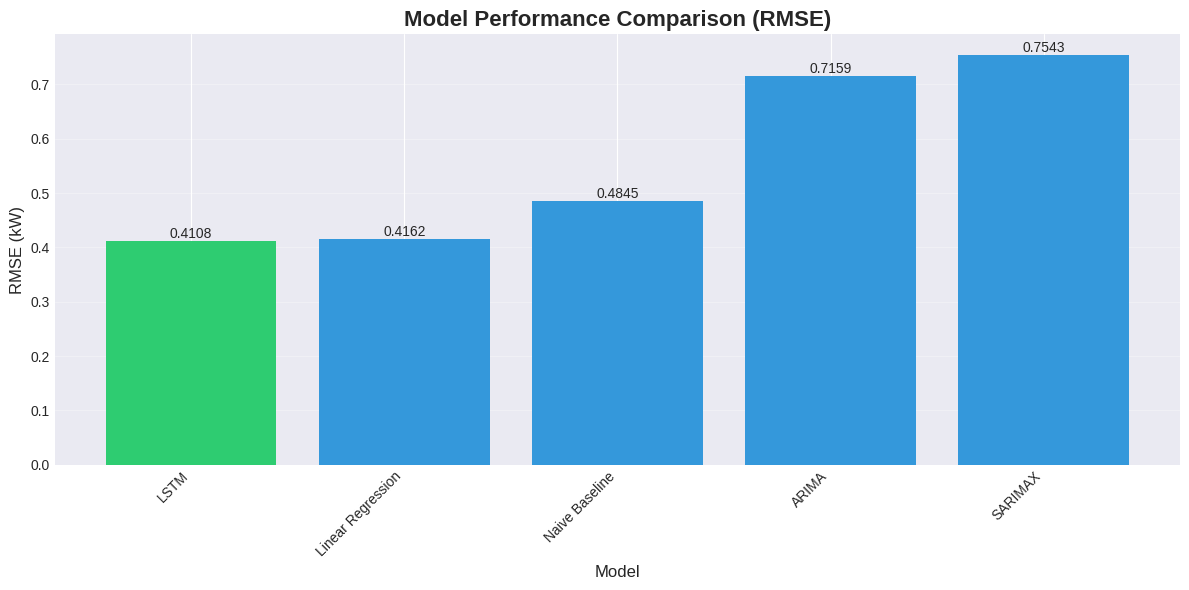


✅ Chart saved to 'model_comparison_chart.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

# Create results dataframe
results_df = pd.DataFrame({
    "Model": ["Naive Baseline", "Linear Regression", "ARIMA", "SARIMAX", "LSTM"],
    "MAE": [naive_mae, lr_mae, arima_mae, sarimax_mae, lstm_mae],
    "RMSE": [naive_rmse, lr_rmse, arima_rmse, sarimax_rmse, lstm_rmse]
})

# Sort by MAE for better presentation
results_df = results_df.sort_values('MAE').reset_index(drop=True)

# Format metrics to 4 decimal places
results_df['MAE'] = results_df['MAE'].apply(lambda x: f"{x:.4f}")
results_df['RMSE'] = results_df['RMSE'].apply(lambda x: f"{x:.4f}")

# Print console version
print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)

# Find best model
best_model = results_df.loc[0, 'Model']
best_mae = results_df.loc[0, 'MAE']
print(f"\n Best Model: {best_model} (MAE: {best_mae} kW)")

# Create publication-ready table for dissertation
print("\n" + "="*60)
print("TABLE FOR DISSERTATION (Copy this into your document)")
print("="*60)

dissertation_table = tabulate(results_df, headers='keys', tablefmt='grid', showindex=False)
print(dissertation_table)

# Save to CSV for inclusion in dissertation
results_df.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to 'model_comparison_results.csv'")

# Create styled bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df["Model"], [float(x) for x in results_df["RMSE"]],
               color=['#2ecc71' if m == best_model else '#3498db' for m in results_df["Model"]])
plt.title('Model Performance Comparison (RMSE)', fontsize=16, fontweight='bold')
plt.ylabel('RMSE (kW)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved to 'model_comparison_chart.png'")